Primeras filas del dataset:


,Temperatura,Hora,Dia_Semana,Consumo_Energia
0,28.891805,1,1,401.990602
1,22.244071,2,2,334.846911
2,20.909006,3,3,326.926080
3,24.983128,4,4,383.016951
4,24.149077,5,5,388.748151


Dimensiones del dataset: (10000, 4)

Columnas:
Index(['Temperatura', 'Hora', 'Dia_Semana', 'Consumo_Energia'], dtype='object')

Tipos de datos:
Temperatura        float64
Hora                 int64
Dia_Semana           int64
Consumo_Energia    float64
dtype: object

Valores nulos:
Temperatura        0
Hora               0
Dia_Semana         0
Consumo_Energia    0
dtype: int64

Estadísticas descriptivas:


,Temperatura,Hora,Dia_Semana,Consumo_Energia
count,10000.000000,10000.000000,10000.00000,10000.000000
mean,24.924793,12.493600,3.99940,400.043522
std,5.004022,6.921297,2.00005,63.825152
min,5.387999,1.000000,1.00000,185.196384
25%,21.578541,6.000000,2.00000,356.735276
50%,24.900520,12.000000,4.00000,399.270398
75%,28.310962,18.000000,6.00000,443.134098
max,44.631189,24.000000,7.00000,631.093191


Intercepto del modelo: 101.28823172887513

Coeficientes del modelo:


,Variable,Coeficiente
0,Temperatura,9.952866
1,Hora,5.019813
2,Dia_Semana,-3.031177


Métricas del modelo:
MSE  : 429.5187
RMSE : 20.7248
R²   : 0.8968

Impacto de las variables:


,Variable,Coeficiente_Estandarizado,Impacto_Absoluto
0,Temperatura,49.662471,49.662471
1,Hora,34.776718,34.776718
2,Dia_Semana,-6.073894,6.073894


La variable con mayor impacto es: Temperatura


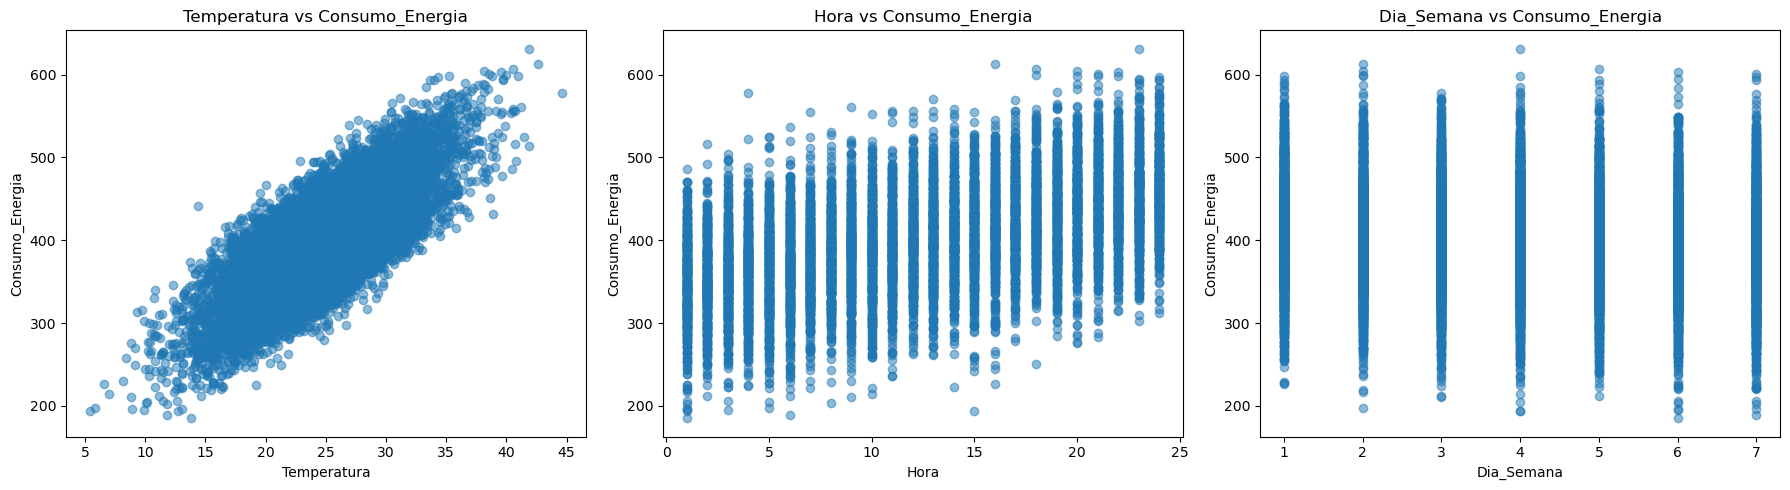

Matriz de correlación:


,Temperatura,Hora,Dia_Semana,Consumo_Energia
Temperatura,1.000000,-0.018589,-0.006855,0.771915
Hora,-0.018589,1.000000,-0.000051,0.528963
Dia_Semana,-0.006855,-0.000051,1.000000,-0.102187
Consumo_Energia,0.771915,0.528963,-0.102187,1.000000


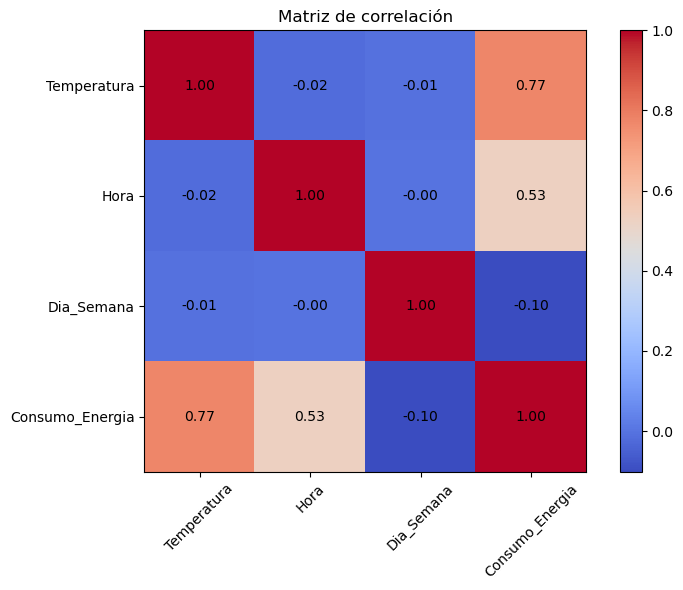

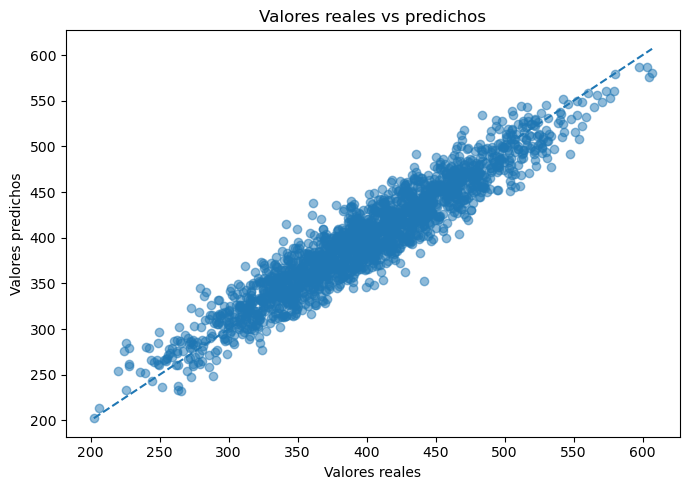

INTERPRETACIÓN DEL MODELO
----------------------------------------
Temperatura: tiene un efecto positivo sobre el consumo de energía (9.9529).
Hora: tiene un efecto positivo sobre el consumo de energía (5.0198).
Dia_Semana: tiene un efecto negativo sobre el consumo de energía (-3.0312).

RMSE del modelo: 20.7248
R² del modelo: 0.8968
La variable con mayor impacto es: Temperatura

Modelo guardado como modelo_energia.joblib
Modelo cargado correctamente.

Conclusión:
Se entrenó un modelo de regresión lineal múltiple para predecir el consumo de energía
a partir de Temperatura, Hora y Dia_Semana.

El modelo obtuvo un R² de 0.8968 y un RMSE de 20.7248, lo que permite evaluar
su capacidad predictiva.

La variable con mayor impacto fue Temperatura, según los coeficientes
estandarizados.



In [1]:
# =========================================
# 1. IMPORTAR LIBRERÍAS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


# =========================================
# 2. CARGAR EL DATASET
# =========================================
df = pd.read_csv("energia_data.csv")

print("Primeras filas del dataset:")
display(df.head())


# =========================================
# 3. EXPLORACIÓN INICIAL DE LOS DATOS
# =========================================
print("Dimensiones del dataset:", df.shape)

print("\nColumnas:")
print(df.columns)

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum())

print("\nEstadísticas descriptivas:")
display(df.describe())


# =========================================
# 4. SEPARAR VARIABLES INDEPENDIENTES Y DEPENDIENTE
# =========================================
X = df[["Temperatura", "Hora", "Dia_Semana"]]
y = df["Consumo_Energia"]


# =========================================
# 5. DIVIDIR EN ENTRENAMIENTO Y PRUEBA
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# =========================================
# 6. ENTRENAR EL MODELO DE REGRESIÓN LINEAL
# =========================================
modelo = LinearRegression()
modelo.fit(X_train, y_train)


# =========================================
# 7. MOSTRAR INTERCEPTO Y COEFICIENTES
# =========================================
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_
})

print("Intercepto del modelo:", modelo.intercept_)
print("\nCoeficientes del modelo:")
display(coeficientes)


# =========================================
# 8. REALIZAR PREDICCIONES Y EVALUAR EL MODELO
# =========================================
y_pred = modelo.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Métricas del modelo:")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


# =========================================
# 9. DETERMINAR LA VARIABLE CON MAYOR IMPACTO
#    Usamos coeficientes estandarizados para comparar
# =========================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_std = LinearRegression()
modelo_std.fit(X_train_scaled, y_train)

impacto = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente_Estandarizado": modelo_std.coef_,
    "Impacto_Absoluto": np.abs(modelo_std.coef_)
}).sort_values(by="Impacto_Absoluto", ascending=False)

print("\nImpacto de las variables:")
display(impacto)

# Aquí estaba tu error: faltaba definir esta variable
variable_mayor_impacto = impacto.iloc[0]["Variable"]

print("La variable con mayor impacto es:", variable_mayor_impacto)


# =========================================
# 10. GRÁFICAS DE DISPERSIÓN
# =========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df["Temperatura"], df["Consumo_Energia"], alpha=0.5)
axes[0].set_title("Temperatura vs Consumo_Energia")
axes[0].set_xlabel("Temperatura")
axes[0].set_ylabel("Consumo_Energia")

axes[1].scatter(df["Hora"], df["Consumo_Energia"], alpha=0.5)
axes[1].set_title("Hora vs Consumo_Energia")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("Consumo_Energia")

axes[2].scatter(df["Dia_Semana"], df["Consumo_Energia"], alpha=0.5)
axes[2].set_title("Dia_Semana vs Consumo_Energia")
axes[2].set_xlabel("Dia_Semana")
axes[2].set_ylabel("Consumo_Energia")

plt.tight_layout()
plt.show()


# =========================================
# 11. MATRIZ DE CORRELACIÓN
# =========================================
corr = df.corr(numeric_only=True)

print("Matriz de correlación:")
display(corr)

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()


# =========================================
# 12. GRÁFICA DE VALORES REALES VS PREDICHOS
# =========================================
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs predichos")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.tight_layout()
plt.show()


# =========================================
# 13. INTERPRETACIÓN DEL MODELO
# =========================================
print("INTERPRETACIÓN DEL MODELO")
print("-" * 40)

for variable, coef in zip(X.columns, modelo.coef_):
    if coef > 0:
        print(f"{variable}: tiene un efecto positivo sobre el consumo de energía ({coef:.4f}).")
    else:
        print(f"{variable}: tiene un efecto negativo sobre el consumo de energía ({coef:.4f}).")

print(f"\nRMSE del modelo: {rmse:.4f}")
print(f"R² del modelo: {r2:.4f}")
print(f"La variable con mayor impacto es: {variable_mayor_impacto}")


# =========================================
# 14. GUARDAR Y CARGAR EL MODELO
# =========================================
joblib.dump(modelo, "modelo_energia.joblib")
print("\nModelo guardado como modelo_energia.joblib")

modelo_cargado = joblib.load("modelo_energia.joblib")
print("Modelo cargado correctamente.")


# =========================================
# 15. CONCLUSIÓN FINAL
# =========================================
print(f"""
Conclusión:
Se entrenó un modelo de regresión lineal múltiple para predecir el consumo de energía
a partir de Temperatura, Hora y Dia_Semana.

El modelo obtuvo un R² de {r2:.4f} y un RMSE de {rmse:.4f}, lo que permite evaluar
su capacidad predictiva.

La variable con mayor impacto fue {variable_mayor_impacto}, según los coeficientes
estandarizados.
""")